# Investigate Unassigned & Artifact_Spillover (UMAP + Leiden)

Companion to `investigate_unassigned_spillover.ipynb`: same question, unsupervised clustering approach.

**Goal:** investigate **Unassigned** and **Artifact_Spillover** cells using single-cell-style embedding (PCA → neighbors → UMAP → Leiden), not by picking per-channel intensity cutoffs.

Binary thresholds are partly subjective, so large Unassigned / spillover pools can reflect cutoff choice, incomplete rules, or real mixed/artifact phenotypes. Clustering in continuous marker space asks: do these cells form coherent neighborhoods, sit between known types, or look like noise?

Related notebooks:
- `investigate_unassigned_spillover.ipynb` — profiles which channels drive those labels
- `determine_binary_threshold.ipynb` / `analyze_cell_types_from_markers.ipynb` — thresholding and rule-based typing (different goal)

## Input

- `../output/celldive_protein_matrix_celltypes.h5ad` — cell × marker matrix (~900k cells × 23 channels) with `cell_type`, QC flags, spatial coords.

## Pipeline

1. **Library-size QC** — histogram of total intensity per cell.
2. **Arcsinh + scale** — transform and z-score markers.
3. **PCA → neighbors** — PC space and kNN graph.
4. **UMAP** — 2D embedding (slow on full data; keep in its own cell).
5. **Leiden** — graph clustering.
6. **Plot (default palette)** — Scanpy's default categorical colors for `cell_type` and Leiden.
7. **Plot (improved palette)** — high-contrast colors + Unassigned/spillover highlight.
8. **Interpret** — what the embedding implies for Unassigned / Artifact_Spillover.
9. **Drill / salvage** — multi-resolution Leiden crosstabs and marker profiles for Unassigned / spillover.
10. **Binary gates** — spillover pair breakdown, binary positivity, phenotyping matrix fit per enriched cluster.

## Notes

- This is **not** threshold / cutoff selection. The arcsinh **cofactor** is a transform hyperparameter, not a positivity gate.
- Steps are split across cells so a failure in plotting does not force re-running UMAP (~hours on full data).
- Per-marker zeros are expected (a CD8 T cell should be ~0 for EPCAM). Empty / near-zero **cells** are a different issue and appear largely filtered already (library-size peak ~25–30k).
- After embedding, consider writing an `.h5ad` so you can reload without recomputing.


## 1. Load data & library-size QC

Sum marker intensities per cell and plot the distribution. Useful sanity check before transforming/clustering.

**How to read it:** a healthy distribution peaks well above zero with a right tail of very bright cells. A pile-up at ~0 would suggest empty/debris cells still present. This plot does **not** by itself explain Unassigned vs spillover.


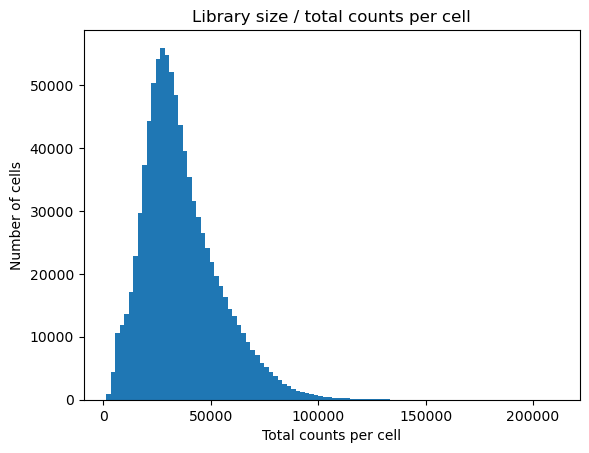

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
adata = sc.read_h5ad("../output/celldive_protein_matrix_celltypes.h5ad")

cell_sums = np.array(adata.X.sum(axis=1)).flatten()
plt.hist(cell_sums, bins=100)
plt.xlabel("Total counts per cell")
plt.ylabel("Number of cells")
plt.title("Library size / total counts per cell")
plt.show()


## 2. Arcsinh transform & scale

Compress imaging dynamic range, keep raw intensities in `layers['raw']`, then z-score markers (clip ±10). Adjust `cofactor` if needed.

This is a continuous-intensity embedding path — we are **not** re-applying binary gates here.


In [2]:
cofactor = 150.0  # may need to play around with this value
adata.layers["raw"] = adata.X.copy()
adata.X = np.arcsinh(adata.X / cofactor)

sc.pp.scale(adata, max_value=10)


## 3. PCA & neighbors

Build PCA and a kNN graph in PC space. With 23 markers, `n_pcs = min(20, n_vars - 1)`.


In [3]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(20, adata.n_vars - 1))


## 4. UMAP

Slow on the full ~900k-cell object. If this succeeds, avoid re-running it unless neighbors/PCA change.

`sc.tl.umap` only **computes** coordinates (`adata.obsm['X_umap']`); it does not draw a figure. Plotting is in §6–§7.


In [4]:
sc.tl.umap(adata)


## 5. Leiden clustering

`resolution=0.5` is moderately coarse (fewer, larger clusters). Raise it for finer partitions.

Leiden finds neighborhoods from marker similarity alone — independent of the rule-based `cell_type` labels.


In [5]:
sc.tl.leiden(adata, resolution=0.5)


/tmp/ipykernel_43740/2104492833.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


### Checkpoint (recommended)

Write an embedding checkpoint so a later crash or kernel restart does **not** force re-running UMAP. Reload with `sc.read_h5ad(...)` and jump to plotting / §9.


In [6]:
from pathlib import Path

CHECKPOINT = Path("../output/celldive_protein_matrix_celltypes_umap_leiden.h5ad")
CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(CHECKPOINT)
print(f"Wrote checkpoint: {CHECKPOINT.resolve()}")
print("Contains: arcsinh+scaled X, PCA, neighbors, X_umap, leiden (r=0.5).")


Wrote checkpoint: /home/steve/Projects/HeLab/BladderDIVE/output/celldive_protein_matrix_celltypes_umap_leiden.h5ad
Contains: arcsinh+scaled X, PCA, neighbors, X_umap, leiden (r=0.5).


## 6. Plot UMAP — default Scanpy palette

Baseline plot with Scanpy's default categorical palette for `cell_type` and Leiden side by side.

**What to look for:**
- Left (`cell_type`): do rule-based labels form clean territories, or mix in the same regions?
- Right (`leiden`): does continuous marker space still show clear structure?
- Especially: do **Unassigned** / **Artifact_Spillover** form one island, or scatter across the manifold?


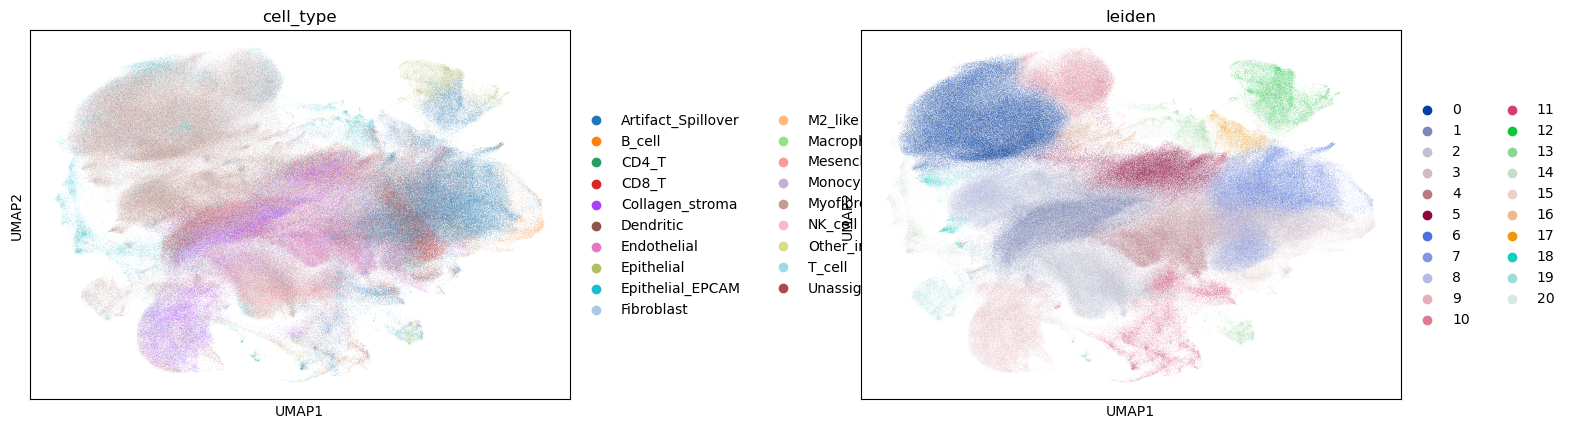

In [7]:
sc.pl.umap(adata, color=["cell_type", "leiden"], wspace=0.4)


### Why improve the palette?

With ~19 cell types on a dense cloud, Scanpy's **default categorical colors are hard to tell apart** (many similar blues, greens, and oranges). That makes the left panel misleading for discussion: you cannot reliably track Unassigned vs spillover vs named types.

We keep §6 unchanged as a baseline, then show the clearer version below. The change is a **visualization** improvement only — not a change to the embedding or clustering math.


## 7. Plot UMAP — improved palette

Same embedding and Leiden clusters as §6; only colors / highlighting change:

- Custom high-contrast palette (`adata.uns["cell_type_colors"]`)
- **Unassigned** = black, **Artifact_Spillover** = magenta
- Light transparency so overlaps remain visible
- Extra plot: only those two labels colored; everything else grey


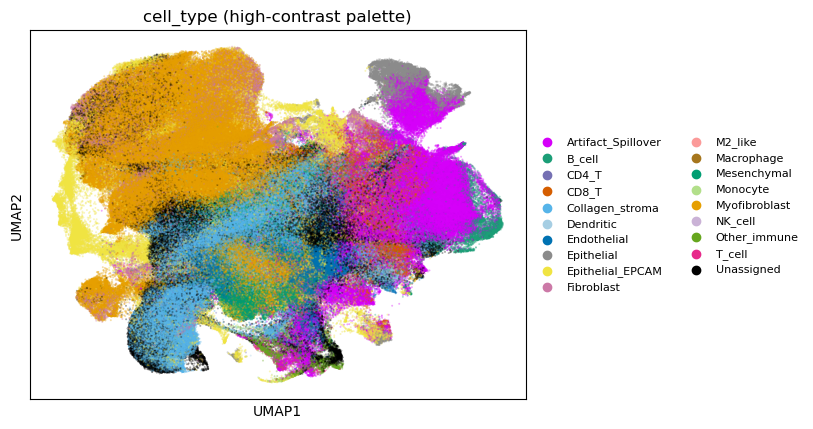

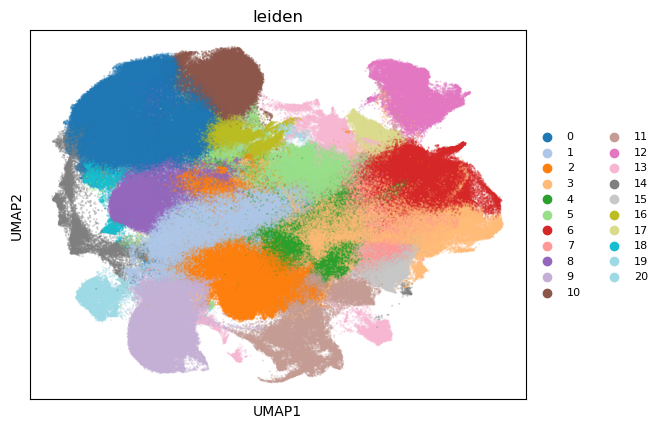

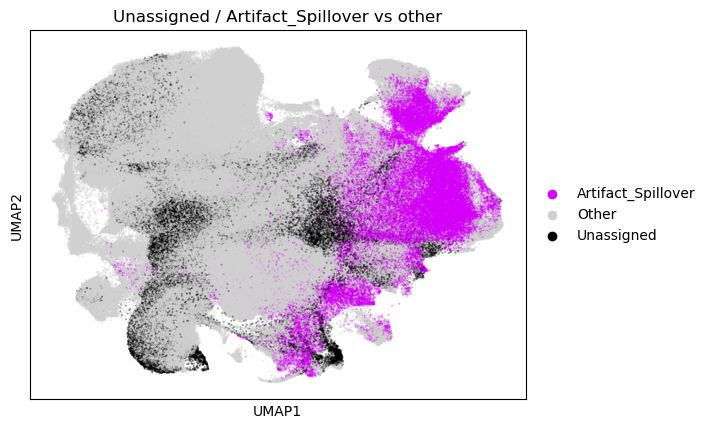

In [8]:
# Distinct categorical colors. Unassigned / Artifact_Spillover get high-salience colors.
CELL_TYPE_COLORS = {
    "Artifact_Spillover": "#D500F9",  # magenta
    "Unassigned": "#000000",  # black
    "Myofibroblast": "#E69F00",
    "Collagen_stroma": "#56B4E9",
    "Mesenchymal": "#009E73",
    "Epithelial_EPCAM": "#F0E442",
    "Endothelial": "#0072B2",
    "Fibroblast": "#CC79A7",
    "CD8_T": "#D55E00",
    "Epithelial": "#8B8B8B",
    "B_cell": "#1B9E77",
    "CD4_T": "#7570B3",
    "T_cell": "#E7298A",
    "Other_immune": "#66A61E",
    "Macrophage": "#A6761D",
    "Dendritic": "#A6CEE3",
    "Monocyte": "#B2DF8A",
    "M2_like": "#FB9A99",
    "NK_cell": "#CAB2D6",
}

adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
adata.uns["cell_type_colors"] = [
    CELL_TYPE_COLORS.get(str(c), "#7F7F7F") for c in adata.obs["cell_type"].cat.categories
]

sc.pl.umap(
    adata,
    color="cell_type",
    size=8,
    alpha=0.35,
    legend_fontsize=8,
    legend_loc="right margin",
    title="cell_type (high-contrast palette)",
)

sc.pl.umap(
    adata,
    color="leiden",
    palette="tab20",
    size=8,
    alpha=0.35,
    legend_fontsize=8,
    legend_loc="right margin",
    title="leiden",
)

# Easier view of where the investigation targets sit
focus = {"Unassigned", "Artifact_Spillover"}
adata.obs["focus_label"] = (
    adata.obs["cell_type"]
    .astype(str)
    .where(adata.obs["cell_type"].astype(str).isin(focus), other="Other")
    .astype("category")
)
adata.uns["focus_label_colors"] = [
    {"Unassigned": "#000000", "Artifact_Spillover": "#D500F9", "Other": "#D0D0D0"}[str(c)]
    for c in adata.obs["focus_label"].cat.categories
]
sc.pl.umap(
    adata,
    color="focus_label",
    size=8,
    alpha=0.4,
    legend_loc="right margin",
    title="Unassigned / Artifact_Spillover vs other",
)


## 8. Interpretation

Use this section to record what the UMAPs imply for Unassigned / Artifact_Spillover. Update after re-plotting if results change.

### Library size
- Peak around ~25–30k total intensity; bulk roughly ~10–75k; long bright tail.
- Not piled at zero → empty / near-zero **cells** look largely filtered already.
- Remaining per-marker zeros are expected biology (negative markers), not evidence that “zeros weren’t removed.”

### Original vs Leiden structure (from §6)
- **Left (`cell_type`):** many rule-based types mix in the main cloud; only a few groups form sharp islands (e.g. bottom-left stroma-like region; small top-right epithelial-like islands).
- **Right (`leiden`):** ~21 contiguous clusters — continuous marker space **does** have structure that binary rules do not cleanly recover.
- That mismatch is the core finding: gating labels and unsupervised neighborhoods disagree in the dense regions.

### What this means for Unassigned / Artifact_Spillover
| Pattern | Interpretation |
|---|---|
| One tight Leiden island dominated by Unassigned or spillover | Coherent leftover class (missing rule or real artifact type) |
| Spread across many Leiden clusters / mixed into named-type clouds | Residues of gate edges, incomplete rules, or mixed phenotypes — not one junk pile |
| Named types that match Leiden islands cleanly | Rule successes; leave those alone |
| Named types split across several Leiden clusters | Heterogeneity or threshold-unstable assignments within that label |

Observed pattern so far: Unassigned / spillover appear **spread through the manifold** rather than as a single remote blob → favors refining rules/thresholds **per neighborhood**, not assuming one global cutoff fix or a single leftover zero-cell artifact.

### Suggested next quantitative checks
```python
pd.crosstab(adata.obs["leiden"], adata.obs["cell_type"], normalize="index")
```
Then inspect marker means for Leiden clusters enriched in Unassigned or Artifact_Spillover (ties back to `investigate_unassigned_spillover.ipynb`).


## 9. Drill into Unassigned / spillover for salvage

Next step after the UMAPs: **drill into Unassigned clusters** and ask whether some cells can be **salvaged** into real phenotypes. Useful quantitative check: **crosstabs of Leiden at several resolutions vs `cell_type`**, plus **marker means per cluster** (especially for spillover-enriched neighborhoods).

Assumes §1–§5 already ran (neighbors graph exists). Re-running UMAP is **not** required.

Plan:
1. Leiden at multiple resolutions (0.5 → 1.0 → 1.5; finer isolates purer spillover neighborhoods).
2. Composition crosstabs: Leiden × `cell_type` (Unassigned / Artifact_Spillover fractions).
3. Marker mean heatmaps for clusters enriched in those labels (size floor + focus gate).
4. Cross-resolution cluster mapping (IDs are not comparable across resolutions).
5. Short salvage candidate table (clusters worth discussing for rule refinement).


### 9.1 Multi-resolution Leiden

Keep the §5 result in `obs['leiden']` (resolution 0.5). Add parallel columns at **1.0** and **1.5** so we can compare composition without overwriting that run.

**Why these resolutions (not 0.3):** coarser (0.3) mainly confirms that Unassigned/spillover form coherent neighborhoods — useful once as a control, but it does not purify marker signatures. Finer resolution (1.5) isolates more homogeneous spillover-heavy clusters so mean marker profiles are less diluted by mixed neighbors. Cluster IDs are **not comparable across resolutions** (each run renumbers by size); use §9.3b to map identity by cell overlap.


In [9]:
# Multi-resolution Leiden on the existing neighbors graph (no UMAP recompute).
# §5 already wrote obs['leiden'] at resolution=0.5; keep it and add named columns.
# Cluster IDs are renumbered independently at each resolution — do not compare
# "cluster 6" across keys. Use the §9.3b mapping table for cross-resolution identity.
LEIDEN_RESOLUTIONS = {
    "leiden": 0.5,       # from §5; kept as the drill key used by §9.5 and §10
    "leiden_r10": 1.0,
    "leiden_r15": 1.5,   # finer: purifies spillover-heavy clusters
}

# Drop stale leiden_* columns from a prior run (e.g. leiden_r03) so they don't
# silently feed into later cells. Keep highlight columns writte                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        n by §9.5.
stale = [
    c
    for c in adata.obs.columns
    if c.startswith("leiden")
    and c not in LEIDEN_RESOLUTIONS
    and not c.endswith("_focus_highlight")
]
if stale:
    adata.obs.drop(columns=stale, inplace=True)
    print(f"Dropped stale Leiden columns: {stale}")

for key, res in LEIDEN_RESOLUTIONS.items():
    if key == "leiden" and "leiden" in adata.obs:
        print(f"{key}: keep existing (§5), n_clusters={adata.obs['leiden'].nunique()}")
        continue
    sc.tl.leiden(adata, resolution=res, key_added=key)
    print(f"{key}: resolution={res}, n_clusters={adata.obs[key].nunique()}")

print("\nLeiden columns:", [c for c in adata.obs.columns if c.startswith("leiden")])


leiden: keep existing (§5), n_clusters=21
leiden_r10: resolution=1.0, n_clusters=34
leiden_r15: resolution=1.5, n_clusters=47

Leiden columns: ['leiden', 'leiden_r10', 'leiden_r15']


### 9.2 Composition crosstabs (Leiden × cell_type)

For each resolution, show row-normalized composition (fraction of each Leiden cluster that is each `cell_type`). Then summarize Unassigned and Artifact_Spillover fractions to find enrichment targets.


In [10]:
from IPython.display import display

FOCUS_LABELS = ["Unassigned", "Artifact_Spillover"]
leiden_keys = [k for k in LEIDEN_RESOLUTIONS if k in adata.obs]

ctabs = {}
focus_summary = {}

for key in leiden_keys:
    # Cast to str so cluster IDs match across crosstab / heatmaps / highlight plots
    leiden_str = adata.obs[key].astype(str)
    ctab = pd.crosstab(leiden_str, adata.obs["cell_type"], normalize="index")
    preferred = [c for c in FOCUS_LABELS if c in ctab.columns] + [
        c for c in ctab.columns if c not in FOCUS_LABELS
    ]
    ctab = ctab.reindex(columns=preferred)
    ctabs[key] = ctab

    focus = ctab.reindex(columns=FOCUS_LABELS, fill_value=0.0).copy()
    focus["focus_total"] = focus[FOCUS_LABELS].sum(axis=1)
    focus["n_cells"] = leiden_str.value_counts().reindex(focus.index).fillna(0).astype(int)
    focus = focus.sort_values("focus_total", ascending=False)
    focus_summary[key] = focus

    print(f"\n=== {key}: row-normalized Leiden × cell_type (top 8 by Unassigned+spillover) ===")
    display(ctab.loc[focus.head(8).index, preferred].style.format("{:.2%}"))
    print(f"\n{key}: Unassigned / Artifact_Spillover enrichment (sorted by focus_total)")
    display(
        focus.head(12).style.format(
            {**{c: "{:.2%}" for c in FOCUS_LABELS + ["focus_total"]}, "n_cells": "{:,}"}
        )
    )



=== leiden: row-normalized Leiden × cell_type (top 8 by Unassigned+spillover) ===


cell_type,Unassigned,Artifact_Spillover,B_cell,CD4_T,CD8_T,Collagen_stroma,Dendritic,Endothelial,Epithelial,Epithelial_EPCAM,Fibroblast,M2_like,Macrophage,Mesenchymal,Monocyte,Myofibroblast,NK_cell,Other_immune,T_cell
leiden,,,,,,,,,,,,,,,,,,,
6,2.17%,75.87%,3.01%,2.02%,10.63%,1.11%,0.18%,0.91%,0.05%,0.31%,0.28%,0.06%,0.26%,1.35%,0.04%,1.02%,0.05%,0.01%,0.66%
3,14.55%,51.64%,6.61%,1.78%,4.87%,2.13%,0.12%,3.69%,0.44%,4.14%,2.66%,0.05%,0.15%,2.17%,0.30%,2.26%,0.02%,0.06%,2.37%
11,8.64%,42.61%,0.93%,0.03%,2.09%,2.82%,0.58%,9.75%,0.10%,1.42%,0.81%,0.36%,0.36%,10.47%,3.47%,3.43%,0.00%,10.43%,1.71%
12,0.07%,49.20%,0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,50.62%,0.08%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
17,0.03%,46.99%,2.08%,2.31%,8.34%,0.00%,0.21%,0.00%,0.72%,1.88%,33.85%,0.13%,1.01%,0.00%,0.28%,0.00%,0.00%,0.01%,2.16%
15,14.43%,25.74%,6.74%,0.11%,13.28%,10.66%,17.40%,3.42%,0.03%,1.38%,0.52%,2.54%,0.46%,0.79%,1.38%,0.64%,0.17%,0.20%,0.10%
7,10.30%,22.96%,0.05%,8.44%,35.42%,9.62%,0.02%,0.93%,0.00%,1.78%,0.90%,0.02%,0.01%,1.27%,0.05%,1.27%,0.18%,0.06%,6.73%
5,29.31%,3.49%,0.47%,0.09%,3.38%,19.64%,0.02%,3.00%,0.10%,5.29%,4.13%,0.28%,2.34%,8.11%,0.01%,19.58%,0.21%,0.00%,0.56%



leiden: Unassigned / Artifact_Spillover enrichment (sorted by focus_total)


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden,,,,
6,2.17%,75.87%,78.04%,"64,457"
3,14.55%,51.64%,66.18%,"74,202"
11,8.64%,42.61%,51.24%,"34,010"
12,0.07%,49.20%,49.27%,"23,051"
17,0.03%,46.99%,47.02%,"7,748"
15,14.43%,25.74%,40.18%,"8,896"
7,10.30%,22.96%,33.25%,"49,525"
5,29.31%,3.49%,32.79%,"65,932"
1,29.32%,0.39%,29.72%,"113,605"



=== leiden_r10: row-normalized Leiden × cell_type (top 8 by Unassigned+spillover) ===


...

cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden_r10,,,,
29,0.13%,86.80%,86.93%,"3,075"
2,1.05%,81.58%,82.63%,"64,562"
32,30.31%,43.72%,74.02%,947
19,0.70%,73.28%,73.98%,"13,760"
5,19.54%,42.35%,61.89%,"48,683"
16,1.30%,49.72%,51.02%,"17,645"
14,0.07%,49.50%,49.57%,"23,205"
24,0.01%,49.38%,49.39%,"8,817"
9,47.15%,0.18%,47.33%,"44,535"



=== leiden_r15: row-normalized Leiden × cell_type (top 8 by Unassigned+spillover) ===


cell_type,Unassigned,Artifact_Spillover,B_cell,CD4_T,CD8_T,Collagen_stroma,Dendritic,Endothelial,Epithelial,Epithelial_EPCAM,Fibroblast,M2_like,Macrophage,Mesenchymal,Monocyte,Myofibroblast,NK_cell,Other_immune,T_cell
leiden_r15,,,,,,,,,,,,,,,,,,,
38,0.14%,86.66%,7.80%,0.57%,2.13%,0.60%,0.00%,0.00%,0.21%,0.00%,1.81%,0.00%,0.00%,0.04%,0.00%,0.00%,0.00%,0.00%,0.04%
30,0.44%,84.49%,9.38%,1.32%,2.73%,0.39%,0.00%,0.47%,0.00%,0.07%,0.00%,0.00%,0.03%,0.53%,0.00%,0.07%,0.00%,0.00%,0.07%
6,0.55%,83.74%,0.05%,2.69%,12.05%,0.07%,0.00%,0.33%,0.01%,0.00%,0.04%,0.00%,0.00%,0.14%,0.01%,0.15%,0.00%,0.00%,0.19%
21,0.82%,79.03%,19.30%,0.01%,0.05%,0.35%,0.00%,0.17%,0.00%,0.14%,0.03%,0.00%,0.00%,0.10%,0.00%,0.01%,0.00%,0.00%,0.00%
42,30.34%,43.80%,0.63%,2.19%,3.02%,0.21%,0.10%,4.69%,0.10%,5.63%,0.00%,0.00%,0.00%,1.04%,0.00%,5.21%,0.00%,0.00%,3.02%
35,63.74%,0.29%,0.00%,0.00%,0.00%,2.03%,0.00%,10.64%,0.06%,13.72%,3.45%,0.03%,0.00%,3.62%,0.00%,2.08%,0.00%,0.29%,0.06%
9,19.12%,44.28%,3.08%,2.05%,5.36%,3.19%,0.07%,3.76%,0.55%,5.15%,3.26%,0.03%,0.00%,3.53%,0.25%,3.03%,0.02%,0.08%,3.18%
14,14.66%,42.25%,3.73%,1.45%,9.14%,6.50%,0.36%,5.22%,0.23%,1.54%,1.81%,0.34%,3.66%,5.55%,0.02%,1.07%,0.11%,0.00%,2.36%



leiden_r15: Unassigned / Artifact_Spillover enrichment (sorted by focus_total)


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden_r15,,,,
38,0.14%,86.66%,86.80%,"2,819"
30,0.44%,84.49%,84.94%,"7,203"
6,0.55%,83.74%,84.28%,"39,814"
21,0.82%,79.03%,79.85%,"18,728"
42,30.34%,43.80%,74.14%,959
35,63.74%,0.29%,64.02%,"3,505"
9,19.12%,44.28%,63.40%,"37,719"
14,14.66%,42.25%,56.91%,"28,954"
26,0.26%,52.42%,52.68%,"10,154"


### 9.3 Marker means for Unassigned / spillover-enriched clusters

For each resolution, take clusters with high Unassigned or Artifact_Spillover fraction and plot mean arcsinh+scaled marker intensity (same `adata.X` as the embedding). Nuclear channels skipped. Companion to the composition crosstabs—especially useful for spillover (multi-lineage / bleed signatures).

**Filter:** clusters with `n < 500` are dropped first (avoids noise rows like a 36-cell cluster clearing a 25% gate). Then keep clusters with Unassigned+spillover ≥ 25%, or the top 10 by that total among eligible clusters. Clusters below the focus threshold are intentionally omitted as relatively clean.



=== leiden: mean marker intensity for Unassigned/spillover-enriched clusters (n=10; gate focus_total≥25% or top 10; min n≥500; dropped 0 for size) ===


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden,,,,
6,2.17%,75.87%,78.04%,"64,457"
3,14.55%,51.64%,66.18%,"74,202"
11,8.64%,42.61%,51.24%,"34,010"
12,0.07%,49.20%,49.27%,"23,051"
17,0.03%,46.99%,47.02%,"7,748"
15,14.43%,25.74%,40.18%,"8,896"
7,10.30%,22.96%,33.25%,"49,525"
5,29.31%,3.49%,32.79%,"65,932"
1,29.32%,0.39%,29.72%,"113,605"


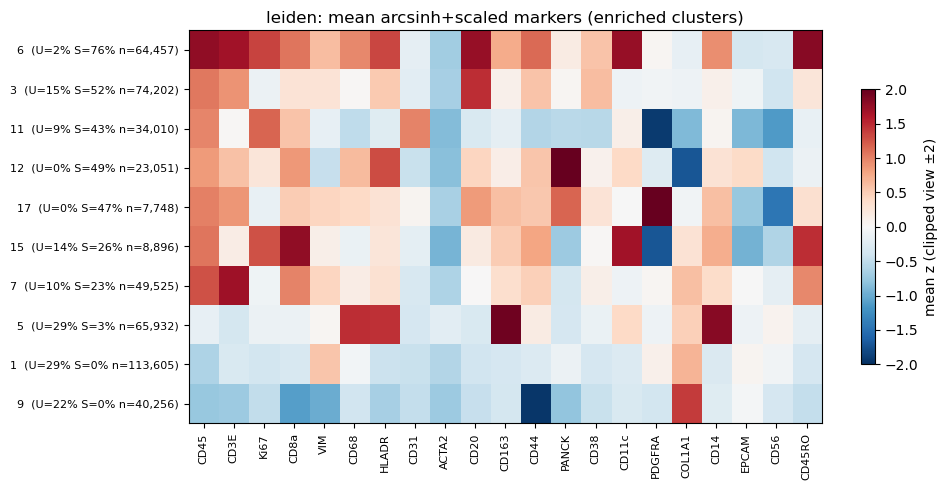


=== leiden_r10: mean marker intensity for Unassigned/spillover-enriched clusters (n=15; gate focus_total≥25% or top 10; min n≥500; dropped 1 for size) ===


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden_r10,,,,
29,0.13%,86.80%,86.93%,"3,075"
2,1.05%,81.58%,82.63%,"64,562"
32,30.31%,43.72%,74.02%,947
19,0.70%,73.28%,73.98%,"13,760"
5,19.54%,42.35%,61.89%,"48,683"
16,1.30%,49.72%,51.02%,"17,645"
14,0.07%,49.50%,49.57%,"23,205"
24,0.01%,49.38%,49.39%,"8,817"
9,47.15%,0.18%,47.33%,"44,535"


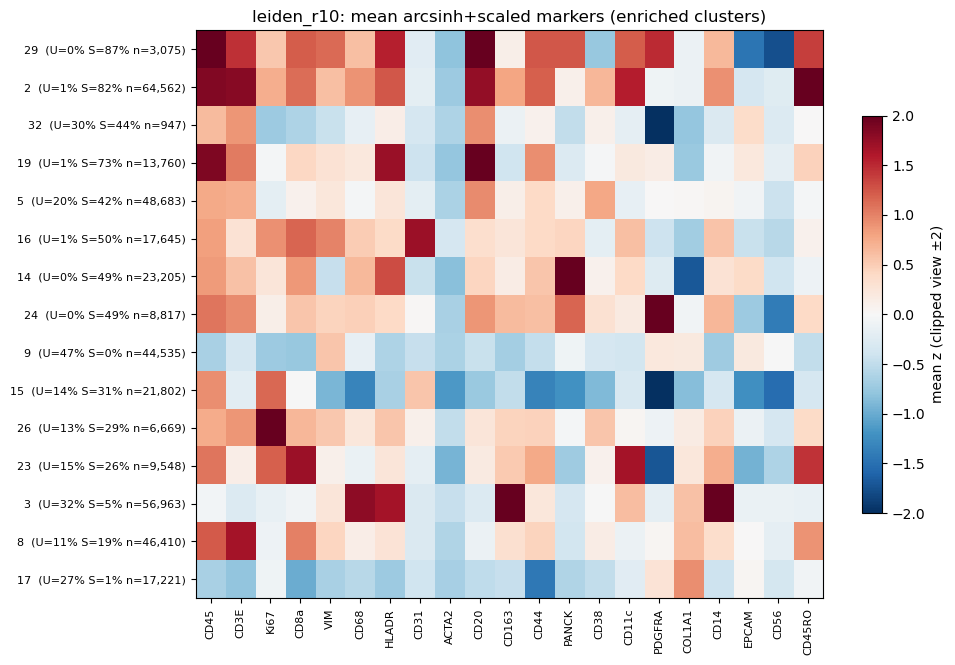


=== leiden_r15: mean marker intensity for Unassigned/spillover-enriched clusters (n=22; gate focus_total≥25% or top 10; min n≥500; dropped 3 for size) ===


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden_r15,,,,
38,0.14%,86.66%,86.80%,"2,819"
30,0.44%,84.49%,84.94%,"7,203"
6,0.55%,83.74%,84.28%,"39,814"
21,0.82%,79.03%,79.85%,"18,728"
42,30.34%,43.80%,74.14%,959
35,63.74%,0.29%,64.02%,"3,505"
9,19.12%,44.28%,63.40%,"37,719"
14,14.66%,42.25%,56.91%,"28,954"
26,0.26%,52.42%,52.68%,"10,154"


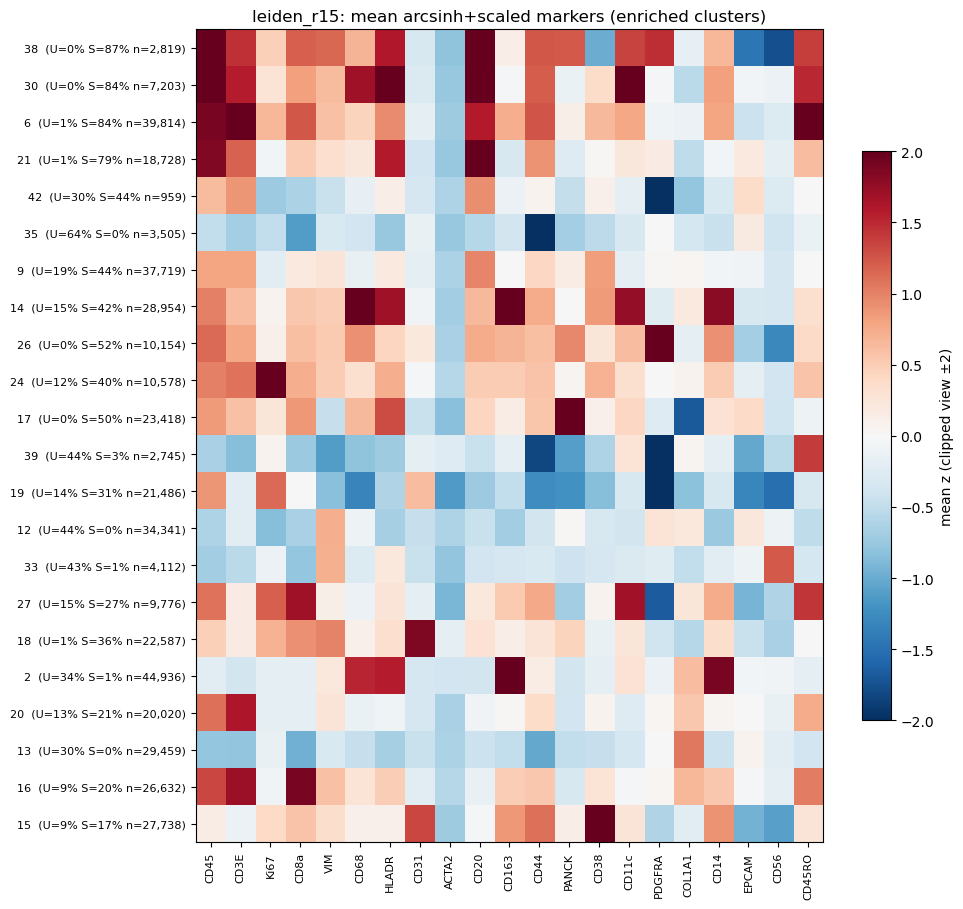

In [11]:
SKIP_MARKERS = {"DAPI", "DAPI2"}
markers = [m for m in adata.var_names if m not in SKIP_MARKERS]
marker_idx = [list(adata.var_names).index(m) for m in markers]

# Enrichment gate: focus label ≥ this fraction, or among top-N by focus_total.
# Size floor is applied first so tiny clusters cannot enter via the top-N branch.
MIN_FOCUS_FRAC = 0.25
TOP_N_CLUSTERS = 10
MIN_CLUSTER_SIZE = 500

cluster_marker_means = {}

for key in leiden_keys:
    focus = focus_summary[key]
    n_dropped_size = int((focus["n_cells"] < MIN_CLUSTER_SIZE).sum())
    eligible = focus[focus["n_cells"] >= MIN_CLUSTER_SIZE]
    enriched = eligible.index[
        (eligible["focus_total"] >= MIN_FOCUS_FRAC)
        | (eligible.index.isin(eligible.head(TOP_N_CLUSTERS).index))
    ].tolist()
    # keep sort by focus_total
    enriched = [c for c in eligible.index if c in set(enriched)]

    rows = []
    for cl in enriched:
        mask = (adata.obs[key].astype(str) == str(cl)).to_numpy()
        if mask.sum() == 0:
            continue
        means = np.asarray(adata.X[mask][:, marker_idx].mean(axis=0)).ravel()
        rows.append(pd.Series(means, index=markers, name=str(cl)))

    mean_df = pd.DataFrame(rows)
    mean_df.index.name = key
    cluster_marker_means[key] = mean_df

    print(
        f"\n=== {key}: mean marker intensity for Unassigned/spillover-enriched clusters "
        f"(n={len(mean_df)}; gate focus_total≥{MIN_FOCUS_FRAC:.0%} or top {TOP_N_CLUSTERS}; "
        f"min n≥{MIN_CLUSTER_SIZE}; dropped {n_dropped_size} for size) ==="
    )
    if mean_df.empty:
        print("No enriched clusters.")
        continue

    # Annotate with Unassigned / spillover fractions for context
    annot = focus.loc[mean_df.index, FOCUS_LABELS + ["focus_total", "n_cells"]]
    display(annot.style.format({**{c: "{:.2%}" for c in FOCUS_LABELS + ["focus_total"]}, "n_cells": "{:,}"}))

    fig, ax = plt.subplots(
        figsize=(max(10, 0.45 * len(markers)), max(3.5, 0.35 * len(mean_df) + 1.5))
    )
    im = ax.imshow(mean_df.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_xticks(range(len(markers)))
    ax.set_xticklabels(markers, rotation=90, fontsize=8)
    ax.set_yticks(range(len(mean_df)))
    ax.set_yticklabels(
        [
            f"{cl}  (U={annot.loc[cl, 'Unassigned']:.0%} S={annot.loc[cl, 'Artifact_Spillover']:.0%} n={annot.loc[cl, 'n_cells']:,})"
            for cl in mean_df.index
        ],
        fontsize=8,
    )
    ax.set_title(f"{key}: mean arcsinh+scaled markers (enriched clusters)")
    fig.colorbar(im, ax=ax, shrink=0.7, label="mean z (clipped view ±2)")
    plt.tight_layout()
    plt.show()


### 9.3b Cross-resolution cluster mapping

Leiden **renumbers clusters from scratch** at each resolution, so "cluster 6" at `leiden` (r=0.5) is unrelated to "cluster 6" at `leiden_r10` / `leiden_r15`. For each Unassigned/spillover-enriched cluster at the base resolution (`leiden`), find the best-matching cluster at finer resolutions by cell overlap (`pd.crosstab`).


In [12]:
BASE = "leiden"
if BASE not in focus_summary:
    raise KeyError(f"{BASE!r} missing from focus_summary; run §9.1–§9.2 first")

base_focus = focus_summary[BASE]
# Use the same enrichment / size gate as the §9.3 heatmap when available
base_clusters = list(cluster_marker_means.get(BASE, pd.DataFrame()).index)
if not base_clusters:
    eligible = base_focus[base_focus["n_cells"] >= MIN_CLUSTER_SIZE]
    base_clusters = eligible.head(TOP_N_CLUSTERS).index.astype(str).tolist()

finer_keys = [k for k in leiden_keys if k != BASE]
if not finer_keys:
    print("No finer Leiden columns to map against.")
else:
    mapping_rows = []
    for key in finer_keys:
        ov = pd.crosstab(
            adata.obs[BASE].astype(str),
            adata.obs[key].astype(str),
        )
        frac = ov.div(ov.sum(axis=1), axis=0)
        for cl in base_clusters:
            if cl not in frac.index:
                continue
            best = frac.loc[cl].idxmax()
            capture = float(frac.loc[cl, best])
            n_base = int(base_focus.loc[cl, "n_cells"]) if cl in base_focus.index else int(ov.loc[cl].sum())
            n_match = int(ov.loc[cl, best]) if best in ov.columns else 0
            mapping_rows.append(
                {
                    "base_cluster": cl,
                    "base_n": n_base,
                    "base_U": float(base_focus.loc[cl, "Unassigned"]) if cl in base_focus.index else float("nan"),
                    "base_S": float(base_focus.loc[cl, "Artifact_Spillover"]) if cl in base_focus.index else float("nan"),
                    "finer_key": key,
                    "best_match": str(best),
                    "capture_frac": capture,
                    "n_overlap": n_match,
                    "match_n": int(adata.obs[key].astype(str).eq(str(best)).sum()),
                }
            )

    map_df = pd.DataFrame(mapping_rows)
    print(
        f"Best-matching clusters for {BASE} (r=0.5) focus clusters "
        f"at finer resolutions (capture_frac = fraction of base cluster cells in the match):"
    )
    display(
        map_df.style.format(
            {
                "base_n": "{:,}",
                "base_U": "{:.1%}",
                "base_S": "{:.1%}",
                "capture_frac": "{:.1%}",
                "n_overlap": "{:,}",
                "match_n": "{:,}",
            }
        )
    )


Best-matching clusters for leiden (r=0.5) focus clusters at finer resolutions (capture_frac = fraction of base cluster cells in the match):


,base_cluster,base_n,base_U,base_S,finer_key,best_match,capture_frac,n_overlap,match_n
0,6,"64,457",2.2%,75.9%,leiden_r10,2,79.7%,"51,375","64,562"
1,3,"74,202",14.5%,51.6%,leiden_r10,5,64.0%,"47,476","48,683"
2,11,"34,010",8.6%,42.6%,leiden_r10,15,56.9%,"19,339","21,802"
3,12,"23,051",0.1%,49.2%,leiden_r10,14,99.8%,"23,009","23,205"
4,17,"7,748",0.0%,47.0%,leiden_r10,24,99.4%,"7,702","8,817"
5,15,"8,896",14.4%,25.7%,leiden_r10,23,97.6%,"8,683","9,548"
6,7,"49,525",10.3%,23.0%,leiden_r10,8,91.1%,"45,114","46,410"
7,5,"65,932",29.3%,3.5%,leiden_r10,3,79.3%,"52,301","56,963"
8,1,"113,605",29.3%,0.4%,leiden_r10,4,44.3%,"50,382","52,976"
9,9,"40,256",21.9%,0.1%,leiden_r10,11,95.2%,"38,312","38,760"


### 9.4 Salvage candidates

Clusters with **high Unassigned** and a **lineage-like marker profile** are salvage candidates (missing/edge rule). Clusters with **high Artifact_Spillover** and **mixed / multi-lineage markers** are less salvageable as a single type—more likely bleed or doublets; still useful for threshold/rule review.

Below: top markers (by mean intensity) for the most enriched clusters at each resolution, plus a compact candidate table.


In [13]:
TOP_MARKERS = 8
N_SHOW = 8  # clusters per resolution

candidate_rows = []

for key in leiden_keys:
    focus = focus_summary[key]
    mean_df = cluster_marker_means.get(key)
    if mean_df is None or mean_df.empty:
        continue

    print(f"\n=== {key}: top markers for Unassigned/spillover-enriched clusters ===")
    for cl in mean_df.index[:N_SHOW]:
        top = mean_df.loc[cl].sort_values(ascending=False).head(TOP_MARKERS)
        u = focus.loc[cl, "Unassigned"]
        s = focus.loc[cl, "Artifact_Spillover"]
        n = int(focus.loc[cl, "n_cells"])
        top_str = ", ".join(f"{m}={v:.2f}" for m, v in top.items())
        print(f"  cluster {cl} (n={n:,}, Unassigned={u:.1%}, Spillover={s:.1%}): {top_str}")

        # Heuristic flags for discussion (not auto-relabeling)
        dominant = "Unassigned" if u >= s else "Artifact_Spillover"
        if u >= 0.35 and s < 0.20:
            note = "Unassigned-heavy → possible salvage / missing rule"
        elif s >= 0.35:
            note = "Spillover-heavy → review bleed / multi-marker gates"
        elif u + s >= 0.40:
            note = "Mixed leftover pool → inspect top markers vs neighbors"
        else:
            note = "Moderate enrichment"
        candidate_rows.append(
            {
                "leiden_key": key,
                "cluster": str(cl),
                "n_cells": n,
                "frac_Unassigned": u,
                "frac_Artifact_Spillover": s,
                "focus_total": u + s,
                "dominant_focus": dominant,
                "top_markers": ", ".join(top.index.tolist()),
                "note": note,
            }
        )

candidates = pd.DataFrame(candidate_rows)
if not candidates.empty:
    candidates = candidates.sort_values(
        ["leiden_key", "focus_total"], ascending=[True, False]
    )
    print("\n=== Salvage / review candidate table ===")
    display(
        candidates.style.format(
            {
                "frac_Unassigned": "{:.1%}",
                "frac_Artifact_Spillover": "{:.1%}",
                "focus_total": "{:.1%}",
                "n_cells": "{:,}",
            }
        )
    )
else:
    print("No candidate clusters.")



=== leiden: top markers for Unassigned/spillover-enriched clusters ===
  cluster 6 (n=64,457, Unassigned=2.2%, Spillover=75.9%): CD45RO=1.83, CD45=1.77, CD11c=1.74, CD20=1.74, CD3E=1.68, Ki67=1.35, HLADR=1.33, CD44=1.13
  cluster 3 (n=74,202, Unassigned=14.5%, Spillover=51.6%): CD20=1.47, CD45=1.05, CD3E=0.89, CD38=0.62, CD44=0.56, HLADR=0.53, VIM=0.27, CD8a=0.27
  cluster 11 (n=34,010, Unassigned=8.6%, Spillover=42.6%): Ki67=1.16, CD31=0.99, CD45=0.98, CD8a=0.57, CD11c=0.12, CD14=0.06, CD3E=0.02, CD45RO=-0.15
  cluster 12 (n=23,051, Unassigned=0.1%, Spillover=49.2%): PANCK=4.92, HLADR=1.31, CD8a=0.86, CD45=0.85, CD68=0.63, CD3E=0.58, CD44=0.55, CD20=0.43
  cluster 17 (n=7,748, Unassigned=0.0%, Spillover=47.0%): PDGFRA=3.44, PANCK=1.16, CD45=1.00, CD3E=0.88, CD20=0.85, CD14=0.61, CD163=0.59, CD44=0.53
  cluster 15 (n=8,896, Unassigned=14.4%, Spillover=25.7%): CD8a=1.77, CD11c=1.68, CD45RO=1.48, Ki67=1.27, CD45=1.07, CD44=0.78, CD14=0.73, CD163=0.51
  cluster 7 (n=49,525, Unassigned=10

,leiden_key,cluster,n_cells,frac_Unassigned,frac_Artifact_Spillover,focus_total,dominant_focus,top_markers,note
0,leiden,6,"64,457",2.2%,75.9%,78.0%,Artifact_Spillover,"CD45RO, CD45, CD11c, CD20, CD3E, Ki67, HLADR, CD44",Spillover-heavy → review bleed / multi-marker gates
1,leiden,3,"74,202",14.5%,51.6%,66.2%,Artifact_Spillover,"CD20, CD45, CD3E, CD38, CD44, HLADR, VIM, CD8a",Spillover-heavy → review bleed / multi-marker gates
2,leiden,11,"34,010",8.6%,42.6%,51.2%,Artifact_Spillover,"Ki67, CD31, CD45, CD8a, CD11c, CD14, CD3E, CD45RO",Spillover-heavy → review bleed / multi-marker gates
3,leiden,12,"23,051",0.1%,49.2%,49.3%,Artifact_Spillover,"PANCK, HLADR, CD8a, CD45, CD68, CD3E, CD44, CD20",Spillover-heavy → review bleed / multi-marker gates
4,leiden,17,"7,748",0.0%,47.0%,47.0%,Artifact_Spillover,"PDGFRA, PANCK, CD45, CD3E, CD20, CD14, CD163, CD44",Spillover-heavy → review bleed / multi-marker gates
5,leiden,15,"8,896",14.4%,25.7%,40.2%,Artifact_Spillover,"CD8a, CD11c, CD45RO, Ki67, CD45, CD44, CD14, CD163",Mixed leftover pool → inspect top markers vs neighbors
6,leiden,7,"49,525",10.3%,23.0%,33.3%,Artifact_Spillover,"CD3E, CD45, CD8a, CD45RO, COL1A1, CD44, VIM, CD14",Moderate enrichment
7,leiden,5,"65,932",29.3%,3.5%,32.8%,Unassigned,"CD163, CD14, CD68, HLADR, COL1A1, CD11c, CD44, CD56",Moderate enrichment
8,leiden_r10,29,"3,075",0.1%,86.8%,86.9%,Artifact_Spillover,"CD20, CD45, HLADR, PDGFRA, CD3E, CD45RO, CD44, PANCK",Spillover-heavy → review bleed / multi-marker gates
9,leiden_r10,2,"64,562",1.1%,81.6%,82.6%,Artifact_Spillover,"CD45RO, CD45, CD3E, CD20, CD11c, HLADR, CD44, CD8a",Spillover-heavy → review bleed / multi-marker gates


### 9.5 UMAP: highlight Unassigned/spillover-enriched Leiden clusters

For **each** Leiden resolution (0.5 / 1.0 / 1.5), map the enriched clusters onto UMAP next to `focus_label` (Unassigned / Artifact_Spillover / Other). Same enrichment gate as §9.3 when available (`n ≥ MIN_CLUSTER_SIZE` and `focus_total ≥ MIN_FOCUS_FRAC`, else top-N). Cluster IDs are **not** comparable across resolutions — use §9.3b for identity.


leiden (r=0.5): highlighting 10 enriched clusters


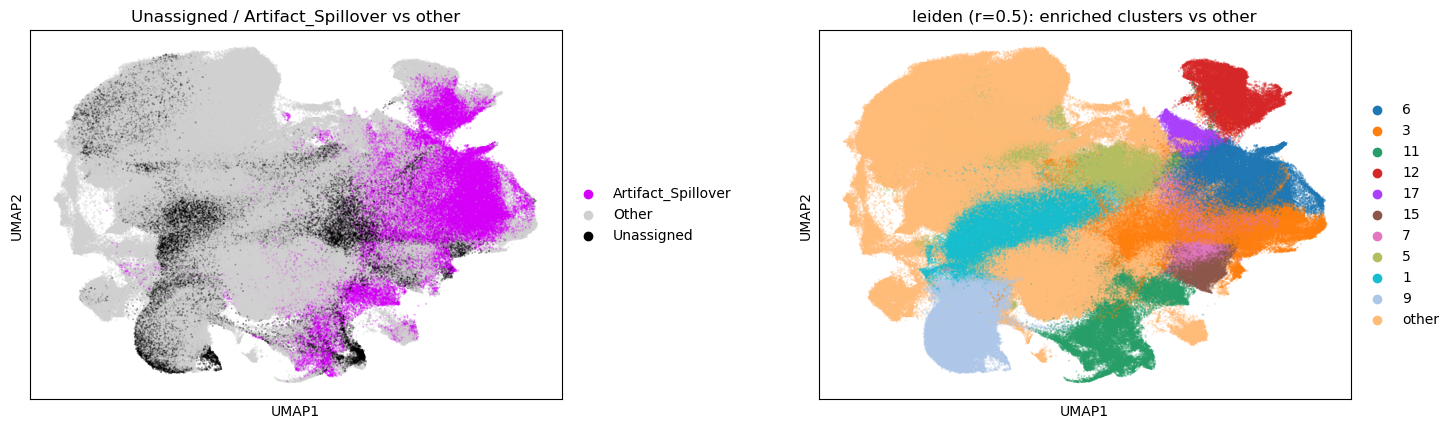

leiden_r10 (r=1.0): highlighting 15 enriched clusters


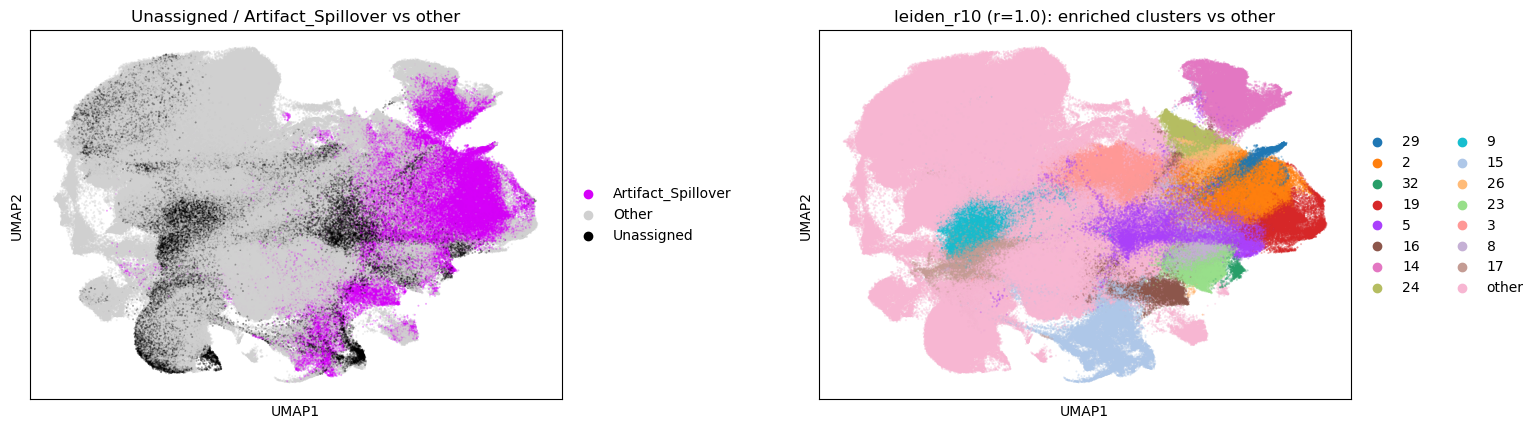

leiden_r15 (r=1.5): highlighting 22 enriched clusters


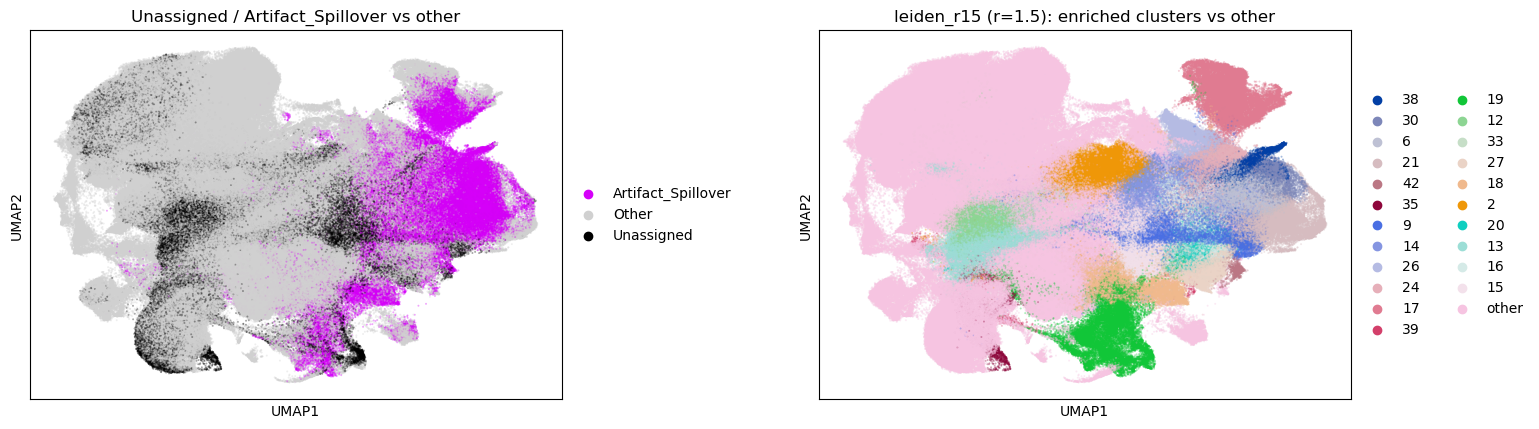

In [14]:
# Side-by-side: focus_label vs enriched Leiden, for every resolution in §9.1.
# Uses the same size/focus gate as §9.3 when those constants exist.
if "focus_label" not in adata.obs.columns:
    focus = {"Unassigned", "Artifact_Spillover"}
    adata.obs["focus_label"] = (
        adata.obs["cell_type"]
        .astype(str)
        .where(adata.obs["cell_type"].astype(str).isin(focus), other="Other")
        .astype("category")
    )

_min_n = globals().get("MIN_CLUSTER_SIZE", 500)
_min_frac = globals().get("MIN_FOCUS_FRAC", 0.25)
_top_n = globals().get("TOP_N_CLUSTERS", 10)

for key in leiden_keys:
    if key not in focus_summary:
        continue
    focus = focus_summary[key]
    eligible = focus[focus["n_cells"] >= _min_n]
    if eligible.empty:
        print(f"{key}: no clusters with n≥{_min_n}; skip")
        continue
    enriched = eligible.index[
        (eligible["focus_total"] >= _min_frac)
        | (eligible.index.isin(eligible.head(_top_n).index))
    ].astype(str).tolist()
    # keep focus_total sort order
    enriched = [c for c in eligible.index.astype(str).tolist() if c in set(enriched)]

    col = f"{key}_focus_highlight"
    adata.obs[col] = (
        adata.obs[key]
        .astype(str)
        .where(adata.obs[key].astype(str).isin(enriched), other="other")
        .astype("category")
    )
    cats = [c for c in enriched if c in adata.obs[col].cat.categories] + (
        ["other"] if "other" in adata.obs[col].cat.categories else []
    )
    adata.obs[col] = adata.obs[col].cat.reorder_categories(cats, ordered=True)

    # Keep legacy name pointing at the §5 (r=0.5) highlight for anything that still expects it
    if key == "leiden":
        adata.obs["leiden_focus_highlight"] = adata.obs[col]

    res = LEIDEN_RESOLUTIONS.get(key, "?")
    print(f"{key} (r={res}): highlighting {len(enriched)} enriched clusters")
    sc.pl.umap(
        adata,
        color=["focus_label", col],
        size=8,
        alpha=0.35,
        wspace=0.35,
        title=[
            "Unassigned / Artifact_Spillover vs other",
            f"{key} (r={res}): enriched clusters vs other",
        ],
    )


## 10. Binary gates & phenotyping matrix (cutoff / salvage diagnostics)

§9 uses **continuous** arcsinh+scaled markers for Leiden and heatmaps. Rule labels (`cell_type`, spillover) come from **`layers['binary']`** and the gates in `analyze_cell_types_from_markers.ipynb`.

This section connects enriched Leiden pockets back to **actionable gate logic**:

1. **Spillover pair breakdown** — which impossible pair(s) fired (CD3E+CD20+, CD45+CD31+, …)?
2. **Binary positivity** — per cluster, compare spillover / Unassigned / assigned cells on each marker.
3. **Phenotyping matrix fit** — which lineage column in `input/Cell Phenotyping Matrix.csv` best matches each cluster's binary profile?

Requires §9 (`focus_summary` from crosstabs). Attaches `layers['binary']` from the source `.h5ad` if the checkpoint lacks it.


### 10.0 Setup — binary layer, spillover gates, drill clusters

Load `layers['binary']` (from checkpoint or source `.h5ad`), define the same spillover pairs as phenotyping, and pick Leiden clusters to drill (from §9 `focus_summary`).

**Drill resolution:** prefer `leiden_r15` (1.5), then `leiden_r10` (1.0), then `leiden` (0.5). Finer clusters make spillover-gate fractions less diluted by mixed assigned cells. Uses the same enrichment gate as §9.3 (`n ≥ 500`, Unassigned+spillover ≥ 25% or top-N).


In [15]:
from pathlib import Path
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SOURCE_H5AD = PROJECT_ROOT / "output" / "celldive_protein_matrix_celltypes.h5ad"
PHENOTYPE_MATRIX = PROJECT_ROOT / "input" / "Cell Phenotyping Matrix.csv"

# Same impossible pairs as analyze_cell_types_from_markers.ipynb
SPILLOVER_GATES: list[tuple[str, str, str]] = [
    ("CD45", "PANCK", "Immune+Epithelial"),
    ("CD45", "CD31", "Immune+Endothelial"),
    ("PANCK", "CD31", "Epithelial+Endothelial"),
    ("CD3E", "CD20", "TCell+BCell"),
]

# Attach binary layer if missing (e.g. after loading a UMAP checkpoint)
if "binary" not in adata.layers:
    src = sc.read_h5ad(SOURCE_H5AD, backed="r")
    if "binary" not in src.layers:
        raise KeyError(f"No layers['binary'] in {SOURCE_H5AD}")
    if not src.obs_names.equals(adata.obs_names):
        raise ValueError("Source .h5ad obs_names do not match adata — cannot attach binary layer.")
    adata.layers["binary"] = np.asarray(src.layers["binary"][:], dtype=np.uint8)
    src.file.close()
    print(f"Attached layers['binary'] from {SOURCE_H5AD}")
else:
    print("Using existing adata.layers['binary']")

X_bin = np.asarray(adata.layers["binary"], dtype=np.uint8)
if hasattr(X_bin, "toarray"):
    X_bin = X_bin.toarray()
marker_to_col = {m: i for i, m in enumerate(adata.var_names)}

ct = adata.obs["cell_type"].astype(str)
mask_spill = (ct == "Artifact_Spillover").to_numpy()
mask_un = (ct == "Unassigned").to_numpy()
mask_assigned = (~mask_spill) & (~mask_un)

# Drill resolution: prefer finer Leiden (1.5) so gate calls are less diluted by mixed neighbors.
# Fall back to 1.0, then §5 (0.5), then whatever §9 produced.
_drill_preference = ("leiden_r15", "leiden_r10", "leiden")
DRILL_KEY = next((k for k in _drill_preference if k in focus_summary), next(iter(focus_summary)))
DRILL_RES = LEIDEN_RESOLUTIONS.get(DRILL_KEY, "?") if "LEIDEN_RESOLUTIONS" in globals() else {
    "leiden": 0.5, "leiden_r10": 1.0, "leiden_r15": 1.5
}.get(DRILL_KEY, "?")

# Same enrichment gate as §9.3 / §9.5 when those constants exist
_min_n = globals().get("MIN_CLUSTER_SIZE", 500)
_min_frac = globals().get("MIN_FOCUS_FRAC", 0.25)
_top_n = globals().get("TOP_N_CLUSTERS", 10)
TOP_N_DRILL = _top_n

focus = focus_summary[DRILL_KEY]
eligible = focus[focus["n_cells"] >= _min_n]
enriched = eligible.index[
    (eligible["focus_total"] >= _min_frac)
    | (eligible.index.isin(eligible.head(_top_n).index))
].astype(str).tolist()
top_clusters = [c for c in eligible.index.astype(str).tolist() if c in set(enriched)]
leiden_str = adata.obs[DRILL_KEY].astype(str).to_numpy()

print(f"DRILL_KEY={DRILL_KEY} (resolution={DRILL_RES})")
print(f"top_clusters ({len(top_clusters)}; n≥{_min_n}, focus≥{_min_frac:.0%} or top {_top_n}): {top_clusters}")
print(
    f"Spillover cells: {mask_spill.sum():,} | Unassigned: {mask_un.sum():,} | Assigned: {mask_assigned.sum():,}"
)

# Phenotyping matrix for §10.3
pm = pd.read_csv(PHENOTYPE_MATRIX)
rename = {"DAPI (1&2)": "DAPI", "COLA1": "COL1A1"}
pm["Marker"] = pm["Marker"].replace(rename)
pm = pm.set_index("Marker")
pm = pm.loc[[m for m in pm.index if m in adata.var_names]]
lineage_cols = list(pm.columns)
print(
    f"Phenotyping matrix: {pm.shape[0]} markers × {len(lineage_cols)} lineages from {PHENOTYPE_MATRIX.name}"
)


def binary_profile(indices: np.ndarray) -> pd.Series:
    """Mean binary positivity per marker for the given cell indices."""
    if len(indices) == 0:
        return pd.Series(0.0, index=list(adata.var_names))
    means = X_bin[indices].mean(axis=0)
    return pd.Series(np.asarray(means).ravel(), index=list(adata.var_names))


Using existing adata.layers['binary']
DRILL_KEY=leiden_r15 (resolution=1.5)
top_clusters (22; n≥500, focus≥25% or top 10): ['38', '30', '6', '21', '42', '35', '9', '14', '26', '24', '17', '39', '19', '12', '33', '27', '18', '2', '20', '13', '16', '15']
Spillover cells: 146,584 | Unassigned: 106,703 | Assigned: 672,719
Phenotyping matrix: 21 markers × 13 lineages from Cell Phenotyping Matrix.csv


### 10.1 Spillover pair breakdown per enriched cluster

For each enriched cluster at `DRILL_KEY` (prefer resolution **1.5**): among **spillover-labeled cells in that cluster**, count which **impossible pair** triggered the flag. This tells you which marker(s) to revisit (e.g. relax CD20 cutoff vs CD3E cutoff for T+B gate).


In [16]:
def spillover_pair_table(indices: np.ndarray) -> pd.DataFrame:
    """Fraction of cells (in indices) positive for each spillover pair."""
    rows = []
    n = len(indices)
    for m1, m2, reason in SPILLOVER_GATES:
        if m1 not in marker_to_col or m2 not in marker_to_col:
            continue
        c1, c2 = marker_to_col[m1], marker_to_col[m2]
        hit = (X_bin[indices, c1] == 1) & (X_bin[indices, c2] == 1)
        rows.append(
            {
                "gate": f"{m1}+ & {m2}+",
                "reason": reason,
                "n_cells": int(hit.sum()),
                "frac_of_subset": hit.sum() / n if n else 0.0,
            }
        )
    return pd.DataFrame(rows).sort_values("frac_of_subset", ascending=False)


pair_rows = []
leiden_str = adata.obs[DRILL_KEY].astype(str).to_numpy()

for cl in top_clusters:
    in_cl = leiden_str == cl
    sp_in_cl = np.where(in_cl & mask_spill)[0]
    n_sp = len(sp_in_cl)
    fu = (ct[in_cl] == "Unassigned").mean()
    fs = (ct[in_cl] == "Artifact_Spillover").mean()
    print(f"\n=== {DRILL_KEY} cluster {cl} (n={in_cl.sum():,}, Unassigned={fu:.1%}, Spillover={fs:.1%}) ===")
    if n_sp == 0:
        print("  No spillover-labeled cells in this cluster.")
        continue
    tbl = spillover_pair_table(sp_in_cl)
    display(tbl.style.format({"frac_of_subset": "{:.1%}"}))
    top_gate = tbl.iloc[0]["gate"] if len(tbl) else ""
    pair_rows.append(
        {
            "cluster": cl,
            "n_spillover_in_cluster": n_sp,
            "top_gate": top_gate,
            "top_gate_frac": tbl.iloc[0]["frac_of_subset"] if len(tbl) else np.nan,
        }
    )

pair_summary = pd.DataFrame(pair_rows)
if not pair_summary.empty:
    print("\n=== Spillover gate summary (top gate per enriched cluster) ===")
    display(pair_summary.style.format({"top_gate_frac": "{:.1%}"}))



=== leiden_r15 cluster 38 (n=2,819, Unassigned=0.1%, Spillover=86.7%) ===


,gate,reason,n_cells,frac_of_subset
3,CD3E+ & CD20+,TCell+BCell,2335,95.6%
0,CD45+ & PANCK+,Immune+Epithelial,308,12.6%
1,CD45+ & CD31+,Immune+Endothelial,251,10.3%
2,PANCK+ & CD31+,Epithelial+Endothelial,24,1.0%



=== leiden_r15 cluster 30 (n=7,203, Unassigned=0.4%, Spillover=84.5%) ===


,gate,reason,n_cells,frac_of_subset
3,CD3E+ & CD20+,TCell+BCell,5945,97.7%
1,CD45+ & CD31+,Immune+Endothelial,683,11.2%
0,CD45+ & PANCK+,Immune+Epithelial,17,0.3%
2,PANCK+ & CD31+,Epithelial+Endothelial,3,0.0%



=== leiden_r15 cluster 6 (n=39,814, Unassigned=0.5%, Spillover=83.7%) ===


...

,gate,reason,n_cells,frac_of_subset
1,CD45+ & CD31+,Immune+Endothelial,3943,75.5%
3,CD3E+ & CD20+,TCell+BCell,1586,30.4%
0,CD45+ & PANCK+,Immune+Epithelial,21,0.4%
2,PANCK+ & CD31+,Epithelial+Endothelial,2,0.0%



=== leiden_r15 cluster 15 (n=27,738, Unassigned=8.6%, Spillover=16.8%) ===


,gate,reason,n_cells,frac_of_subset
1,CD45+ & CD31+,Immune+Endothelial,4172,89.3%
3,CD3E+ & CD20+,TCell+BCell,833,17.8%
2,PANCK+ & CD31+,Epithelial+Endothelial,132,2.8%
0,CD45+ & PANCK+,Immune+Epithelial,46,1.0%



=== Spillover gate summary (top gate per enriched cluster) ===


,cluster,n_spillover_in_cluster,top_gate,top_gate_frac
0,38,2443,CD3E+ & CD20+,95.6%
1,30,6086,CD3E+ & CD20+,97.7%
2,6,33340,CD3E+ & CD20+,93.2%
3,21,14801,CD3E+ & CD20+,99.0%
4,42,420,CD3E+ & CD20+,98.6%
5,35,10,CD45+ & CD31+,100.0%
6,9,16702,CD3E+ & CD20+,88.1%
7,14,12232,CD3E+ & CD20+,69.5%
8,26,5323,CD3E+ & CD20+,64.3%
9,24,4181,CD3E+ & CD20+,77.0%


### 10.2 Binary positivity per cluster (spillover vs Unassigned vs assigned)

Fraction **binary-positive** per marker, split by label within each enriched cluster. Compare to **assigned clean** cells globally (reference). Large deltas hint at cutoff tweaks or missing rules.

- **Spillover rows:** which channel is weakly positive and could be thresholded down?
- **Unassigned rows:** which lineage markers are high but didn't complete a rule (e.g. CD14+ without CD45+)?


In [17]:
SKIP_FOR_POS = {"DAPI", "DAPI2"}
pos_markers = [m for m in adata.var_names if m not in SKIP_FOR_POS]

# Global assigned reference
ref_assigned = binary_profile(np.where(mask_assigned)[0]).reindex(pos_markers)

pos_tables = {}
for cl in top_clusters:
    in_cl = leiden_str == cl
    rows = {}
    for label, mask in [
        ("Spillover", mask_spill),
        ("Unassigned", mask_un),
        ("Assigned_in_cluster", mask_assigned),
    ]:
        idx = np.where(in_cl & mask)[0]
        if len(idx) < 20:
            continue
        rows[label] = binary_profile(idx).reindex(pos_markers)
    if not rows:
        continue
    df = pd.DataFrame(rows)
    df["Assigned_global"] = ref_assigned
    if "Spillover" in df.columns:
        df["delta_Spillover_vs_Assigned"] = df["Spillover"] - df["Assigned_global"]
    if "Unassigned" in df.columns:
        df["delta_Unassigned_vs_Assigned"] = df["Unassigned"] - df["Assigned_global"]
    pos_tables[cl] = df

    fu = (
        float(focus_summary[DRILL_KEY].loc[cl, "Unassigned"])
        if cl in focus_summary[DRILL_KEY].index
        else float("nan")
    )
    fs = (
        float(focus_summary[DRILL_KEY].loc[cl, "Artifact_Spillover"])
        if cl in focus_summary[DRILL_KEY].index
        else float("nan")
    )
    print(f"\n=== {DRILL_KEY} cluster {cl}: binary positivity (U={fu:.1%}, S={fs:.1%}) ===")
    sort_col = (
        "delta_Spillover_vs_Assigned"
        if "delta_Spillover_vs_Assigned" in df.columns
        else (
            "delta_Unassigned_vs_Assigned"
            if "delta_Unassigned_vs_Assigned" in df.columns
            else df.columns[0]
        )
    )
    show = df.reindex(df[sort_col].abs().sort_values(ascending=False).index)
    display(
        show.head(15)
        .style.format("{:.1%}")
        .background_gradient(cmap="RdBu_r", axis=None, vmin=-0.5, vmax=0.5)
    )



=== leiden_r15 cluster 38: binary positivity (U=0.1%, S=86.7%) ===


,Spillover,Assigned_in_cluster,Assigned_global,delta_Spillover_vs_Assigned
CD20,99.1%,76.1%,3.8%,95.3%
CD45,98.2%,79.8%,10.2%,88.1%
PDGFRA,91.5%,89.8%,11.1%,80.4%
CD3E,96.5%,23.9%,19.0%,77.5%
CD8a,98.5%,84.9%,28.0%,70.5%
HLADR,99.9%,98.4%,36.7%,63.2%
CD45RO,71.6%,27.7%,10.4%,61.2%
VIM,79.7%,67.7%,24.8%,54.9%
CD14,97.3%,99.7%,43.1%,54.1%
CD44,59.4%,36.3%,5.9%,53.5%



=== leiden_r15 cluster 30: binary positivity (U=0.4%, S=84.5%) ===


,Spillover,Unassigned,Assigned_in_cluster,Assigned_global,delta_Spillover_vs_Assigned,delta_Unassigned_vs_Assigned
CD20,99.5%,96.9%,72.1%,3.8%,95.8%,93.1%
CD11c,100.0%,100.0%,100.0%,6.4%,93.6%,93.6%
CD45,98.9%,0.0%,89.9%,10.2%,88.7%,-10.2%
CD3E,98.2%,0.0%,27.5%,19.0%,79.2%,-19.0%
HLADR,100.0%,100.0%,100.0%,36.7%,63.3%,63.3%
CD45RO,72.3%,15.6%,32.5%,10.4%,61.9%,5.2%
CD14,95.4%,75.0%,92.0%,43.1%,52.3%,31.9%
CD68,56.7%,87.5%,55.5%,6.8%,49.9%,80.7%
CD8a,77.5%,9.4%,36.4%,28.0%,49.4%,-18.7%
CD44,53.6%,12.5%,29.7%,5.9%,47.7%,6.6%



=== leiden_r15 cluster 6: binary positivity (U=0.5%, S=83.7%) ===


...

,Spillover,Unassigned,Assigned_in_cluster,Assigned_global,delta_Spillover_vs_Assigned,delta_Unassigned_vs_Assigned
CD45,84.0%,0.0%,0.6%,10.2%,73.8%,-10.2%
CD31,88.0%,0.0%,6.8%,22.8%,65.2%,-22.8%
Ki67,52.0%,0.4%,0.6%,6.3%,45.7%,-5.9%
ACTA2,4.0%,0.0%,2.9%,48.1%,-44.1%,-48.1%
PDGFRA,52.0%,0.0%,10.4%,11.1%,40.9%,-11.1%
COL1A1,52.0%,0.0%,84.2%,23.6%,28.4%,-23.6%
CD3E,44.0%,0.2%,0.5%,19.0%,25.0%,-18.8%
VIM,0.0%,0.0%,5.6%,24.8%,-24.8%,-24.8%
CD8a,4.0%,0.6%,1.3%,28.0%,-24.0%,-27.5%
CD56,0.0%,1.9%,3.1%,23.1%,-23.1%,-21.2%



=== leiden_r15 cluster 16: binary positivity (U=8.9%, S=19.6%) ===


,Spillover,Unassigned,Assigned_in_cluster,Assigned_global,delta_Spillover_vs_Assigned,delta_Unassigned_vs_Assigned
CD45,96.3%,0.0%,78.0%,10.2%,86.2%,-10.2%
CD3E,100.0%,91.9%,98.6%,19.0%,81.0%,72.9%
CD8a,98.9%,98.0%,98.6%,28.0%,70.9%,69.9%
CD45RO,73.1%,44.1%,62.0%,10.4%,62.6%,33.7%
CD31,75.8%,0.0%,2.9%,22.8%,53.0%,-22.8%
HLADR,88.8%,57.3%,75.9%,36.7%,52.0%,20.5%
CD14,85.8%,56.4%,74.7%,43.1%,42.6%,13.3%
ACTA2,5.8%,0.0%,7.7%,48.1%,-42.3%,-48.1%
CD38,49.8%,3.7%,9.3%,11.2%,38.6%,-7.4%
VIM,54.5%,0.0%,40.1%,24.8%,29.8%,-24.8%



=== leiden_r15 cluster 15: binary positivity (U=8.6%, S=16.8%) ===


,Spillover,Unassigned,Assigned_in_cluster,Assigned_global,delta_Spillover_vs_Assigned,delta_Unassigned_vs_Assigned
CD38,96.4%,64.0%,90.4%,11.2%,85.2%,52.8%
CD45,91.2%,0.0%,1.2%,10.2%,81.0%,-10.2%
CD31,96.9%,0.0%,87.9%,22.8%,74.0%,-22.8%
CD44,75.8%,7.7%,45.5%,5.9%,70.0%,1.8%
CD8a,88.5%,29.5%,66.2%,28.0%,60.4%,1.5%
CD14,98.7%,89.9%,96.6%,43.1%,55.6%,46.8%
HLADR,84.0%,52.4%,63.1%,36.7%,47.3%,15.7%
ACTA2,3.7%,0.0%,6.0%,48.1%,-44.4%,-48.1%
CD45RO,53.9%,15.8%,24.0%,10.4%,43.4%,5.4%
CD3E,61.5%,13.1%,14.8%,19.0%,42.6%,-5.9%


### 10.3 Phenotyping matrix lineage fit

Score each enriched cluster's **mean binary profile** against lineage columns in `input/Cell Phenotyping Matrix.csv`:

- **`+`** expects ≥50% binary-positive in cluster  
- **`-`** expects ≤50% binary-positive  
- **`+/-`** is neutral (not scored)

Best-matching lineage suggests a **salvage label** or which matrix row to align rules with. Low scores across all columns → genuinely ambiguous / needs new rule or cutoff work.


In [18]:
def score_lineage(profile: pd.Series, expect: pd.Series) -> tuple[float, int]:
    """Return (score, n_scored). +1 match, -1 mismatch per scored marker."""
    score, n = 0.0, 0
    for marker, req in expect.items():
        if marker not in profile.index:
            continue
        req = str(req).strip()
        if req in ("+", "-"):
            n += 1
            pos = profile[marker] >= 0.5
            if (req == "+" and pos) or (req == "-" and not pos):
                score += 1
            else:
                score -= 1
    return score, n


def best_lineages(profile: pd.Series, top_k: int = 3) -> pd.DataFrame:
    rows = []
    for col in lineage_cols:
        s, n = score_lineage(profile, pm[col])
        if n == 0:
            continue
        rows.append(
            {
                "lineage": col,
                "score": s,
                "n_scored": n,
                "pct_match": (s + n) / (2 * n),  # maps [-1,1] to [0,1]
            }
        )
    return pd.DataFrame(rows).sort_values(["score", "pct_match"], ascending=False).head(top_k)


# Pipeline rules (for cross-reference with matrix)
PIPELINE_RULES = [
    ("CD8_T", ["CD45", "CD3E", "CD8a"], []),
    ("CD4_T", ["CD45", "CD3E", "CD45RO"], ["CD8a"]),
    ("T_cell", ["CD45", "CD3E"], []),
    ("B_cell", ["CD45", "CD20"], []),
    ("NK_cell", ["CD45", "CD56"], ["CD3E"]),
    ("Macrophage", ["CD45", "CD68"], []),
    ("M2_like", ["CD45", "CD163"], []),
    ("Monocyte", ["CD45", "CD14"], []),
    ("Other_immune", ["CD45"], []),
    ("Epithelial", ["PANCK"], []),
    ("Epithelial_EPCAM", ["EPCAM"], []),
    ("Fibroblast", ["PDGFRA"], []),
    ("Myofibroblast", ["ACTA2"], []),
    ("Collagen_stroma", ["COL1A1"], []),
    ("Mesenchymal", ["VIM"], []),
    ("Endothelial", ["CD31"], []),
]


def matching_pipeline_rules(profile: pd.Series) -> list[str]:
    hits = []
    for name, pos, neg in PIPELINE_RULES:
        pos_ok = all(profile.get(m, 0) >= 0.5 for m in pos if m in profile.index)
        neg_ok = all(profile.get(m, 1) <= 0.5 for m in neg if m in profile.index)
        if pos_ok and neg_ok:
            hits.append(name)
    return hits


fit_rows = []
for cl in top_clusters:
    in_cl = leiden_str == cl
    idx_un = np.where(in_cl & mask_un)[0]
    idx_sp = np.where(in_cl & mask_spill)[0]
    idx_all = np.where(in_cl)[0]

    fu = (ct[in_cl] == "Unassigned").mean()
    fs = (ct[in_cl] == "Artifact_Spillover").mean()

    print(f"\n=== {DRILL_KEY} cluster {cl}: lineage & rule fit ===")
    for label, idx in [
        ("all cells in cluster", idx_all),
        ("Unassigned subset", idx_un),
        ("Spillover subset", idx_sp),
    ]:
        if len(idx) < 30:
            continue
        prof = binary_profile(idx)
        print(f"\n  [{label}] n={len(idx):,}")
        display(best_lineages(prof).style.format({"pct_match": "{:.0%}"}))
        rules = matching_pipeline_rules(prof)
        if rules:
            print(f"  Pipeline rules fully satisfied (binary): {', '.join(rules)}")
        else:
            print("  Pipeline rules fully satisfied (binary): none")
        fit_rows.append(
            {
                "cluster": cl,
                "subset": label,
                "n": len(idx),
                "best_lineage": best_lineages(prof).iloc[0]["lineage"] if len(best_lineages(prof)) else "",
                "best_lineage_pct": best_lineages(prof).iloc[0]["pct_match"] if len(best_lineages(prof)) else np.nan,
                "pipeline_rules_match": ", ".join(rules) if rules else "",
                "frac_Unassigned": fu,
                "frac_Spillover": fs,
            }
        )

fit_summary = pd.DataFrame(fit_rows)
if not fit_summary.empty:
    print("\n=== Lineage / rule fit summary (enriched clusters) ===")
    display(
        fit_summary.style.format(
            {
                "best_lineage_pct": "{:.0%}",
                "frac_Unassigned": "{:.1%}",
                "frac_Spillover": "{:.1%}",
            }
        )
    )



=== leiden_r15 cluster 38: lineage & rule fit ===

  [all cells in cluster] n=2,819


,lineage,score,n_scored,pct_match
4,T cell CD8,10.000000,18,78%
5,T cell other,8.000000,18,72%
11,All Leukocytes (CD45+ mask),7.000000,7,100%


  Pipeline rules fully satisfied (binary): CD8_T, T_cell, B_cell, Monocyte, Other_immune, Fibroblast, Mesenchymal

  [Spillover subset] n=2,443


,lineage,score,n_scored,pct_match
4,T cell CD8,10.000000,18,78%
5,T cell other,8.000000,18,72%
11,All Leukocytes (CD45+ mask),7.000000,7,100%


  Pipeline rules fully satisfied (binary): CD8_T, T_cell, B_cell, Monocyte, Other_immune, Fibroblast, Mesenchymal

=== leiden_r15 cluster 30: lineage & rule fit ===

  [all cells in cluster] n=7,203


...

,lineage,score,n_scored,pct_match
8,M1-like Macrophage,13.000000,17,88%
6,B / Plasma cell,11.000000,17,82%
9,M2-like Macrophage,11.000000,17,82%


  Pipeline rules fully satisfied (binary): none

  [Spillover subset] n=4,670


,lineage,score,n_scored,pct_match
4,T cell CD8,14.000000,18,89%
5,T cell other,12.000000,18,83%
6,B / Plasma cell,7.000000,17,71%


  Pipeline rules fully satisfied (binary): CD8_T, T_cell, Monocyte, Other_immune, Endothelial

=== Lineage / rule fit summary (enriched clusters) ===


,cluster,subset,n,best_lineage,best_lineage_pct,pipeline_rules_match,frac_Unassigned,frac_Spillover
0,38,all cells in cluster,2819,T cell CD8,78%,"CD8_T, T_cell, B_cell, Monocyte, Other_immune, Fibroblast, Mesenchymal",0.1%,86.7%
1,38,Spillover subset,2443,T cell CD8,78%,"CD8_T, T_cell, B_cell, Monocyte, Other_immune, Fibroblast, Mesenchymal",0.1%,86.7%
2,30,all cells in cluster,7203,T cell CD8,72%,"CD8_T, T_cell, B_cell, Macrophage, Monocyte, Other_immune",0.4%,84.5%
3,30,Unassigned subset,32,M1-like Macrophage,82%,,0.4%,84.5%
4,30,Spillover subset,6086,T cell CD8,78%,"CD8_T, T_cell, B_cell, Macrophage, Monocyte, Other_immune",0.4%,84.5%
5,6,all cells in cluster,39814,T cell CD8,89%,"CD8_T, T_cell, B_cell, Monocyte, Other_immune",0.5%,83.7%
6,6,Unassigned subset,217,T cell CD8,78%,,0.5%,83.7%
7,6,Spillover subset,33340,T cell CD8,89%,"CD8_T, T_cell, B_cell, Monocyte, Other_immune",0.5%,83.7%
8,21,all cells in cluster,18728,T cell CD8,78%,"CD8_T, T_cell, B_cell, Monocyte, Other_immune",0.8%,79.0%
9,21,Unassigned subset,153,B / Plasma cell,88%,,0.8%,79.0%


## 11. View Leiden clusters in Napari

Render each Leiden cluster as its own **outline** layer over the CellDIVE image, using the same Cellpose segmentation boundaries as the existing mask layer. One toggleable layer per cluster, so a single cluster can be isolated on the slide.

**Requirements**

- Run in the `napari-env` conda environment (`napari 0.6.6`); the base env has no napari.
- Needs `output/cellpose_output/cellpose_masks_dapi_only_9tiles.zarr` and `data/CellDIVE_SLIDE-045.zarr`.
- `obs['cell_id']` indexes the mask labels 1:1. Label `0` is background (~92% of the slide) and is excluded — it carries a real `leiden` value in `obs`, so including it would flood the slide with that cluster's color.
- Safe after a kernel restart: if `adata` is missing, the next cell loads `output/celldive_protein_matrix_celltypes_umap_leiden.h5ad` (written by the §5 checkpoint).

**Scope:** this shows **`leiden_r15` (resolution 1.5)** — finer than the default §5 `leiden` (0.5), so spillover neighborhoods are more homogeneous. If `leiden_r15` is not already in `obs` (e.g. after a restart before §9.1), the next cell computes it from the checkpoint neighbors graph (a few minutes on ~926k cells).

Outlines are drawn per cell (each cell keeps its own segmentation label), so touching cells in the same cluster stay visually separate instead of merging into one blob. Set `cells_contour_width=0` for the old filled rendering.


In [19]:
import sys
from pathlib import Path

import anndata as ad
import scanpy as sc

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.napari_load_image_adata import open_napari_with_adata

NAPARI_COLUMN = "leiden_r15"  # resolution 1.5 (finer than §5 leiden at 0.5)
NAPARI_RESOLUTION = 1.5
CHECKPOINT = PROJECT_ROOT / "output" / "celldive_protein_matrix_celltypes_umap_leiden.h5ad"

# Survive kernel restart / Cursor crash: reload from §5 checkpoint if needed.
if "adata" not in globals():
    if not CHECKPOINT.exists():
        raise FileNotFoundError(
            f"No in-memory adata, and checkpoint missing: {CHECKPOINT}\n"
            "Re-run §1–§5 (or at least the checkpoint cell) first."
        )
    adata = ad.read_h5ad(CHECKPOINT)
    print(f"Loaded checkpoint: {CHECKPOINT}  (n={adata.n_obs:,})")

if NAPARI_COLUMN not in adata.obs.columns:
    if "neighbors" not in adata.uns and "connectivities" not in adata.obsp:
        raise RuntimeError(
            f"{NAPARI_COLUMN!r} missing and no neighbors graph to compute it. "
            "Re-run §3 (neighbors) / §9.1, or load the embedding checkpoint."
        )
    print(f"Computing {NAPARI_COLUMN} at resolution={NAPARI_RESOLUTION} (may take a few minutes)...")
    sc.tl.leiden(adata, resolution=NAPARI_RESOLUTION, key_added=NAPARI_COLUMN)
    print(f"{NAPARI_COLUMN}: n_clusters={adata.obs[NAPARI_COLUMN].nunique()}")

viewer = open_napari_with_adata(
    adata,
    color_column=NAPARI_COLUMN,
    project_root=PROJECT_ROOT,
    display_mode="cells",
    cells_contour_width=1,  # per-cell outline; 0 = filled cells
    add_mask_layer=True,
)
print(f"{adata.obs[NAPARI_COLUMN].nunique()} clusters -> one outline layer each.")


Loaded Cellpose segmentation as Labels layer (multiscale pyramid, contour=1)
Loaded 47 leiden_r15 outline layers (contour=1, multiscale pyramid)
47 clusters -> one outline layer each.
